# Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## Objective
The objective of this project is to analyze buyer demographics, financing behavior, acquisition purpose, and property transaction behavior to identify meaningful buyer segments using clustering techniques. The project also aims to support investment profiling and business recommendations for real estate market intelligence.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

## Load Datasets

In [5]:
clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

In [6]:
print("Clients shape:", clients.shape)
print("Properties shape:", properties.shape)

Clients shape: (2000, 12)
Properties shape: (10000, 9)


In [7]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [8]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


## Initial Data Inspection

In [10]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [11]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [12]:
clients.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [13]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [14]:
clients.describe(include='all')

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000.000000,2000,2000
unique,2000,2,337,224,1889,2,10,57,2,NaN,2,3
top,C0001,Individual,Carl,Co,6/14/1993,M,USA,California,Home,NaN,No,Website
freq,1,1897,24,103,3,1012,1538,633,1385,NaN,1264,1103
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.029000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.413562,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN


In [15]:
properties.describe(include='all')

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
count,10000.000000,10000.000000,10000,10000,10000.00000,10000.000000,10000,10000,7305
unique,NaN,NaN,24,2,NaN,NaN,9998,2,2000
top,NaN,NaN,06-01-2024,Apartment,NaN,NaN,"$460,001.26",Sold,C0005
freq,NaN,NaN,537,8547,NaN,NaN,2,7305,13
mean,105898.277400,10.370100,NaN,NaN,28.99920,1139.941412,NaN,NaN,NaN
std,74414.566199,5.769025,NaN,NaN,16.88242,418.373967,NaN,NaN,NaN
min,1002.000000,1.000000,NaN,NaN,1.00000,410.710000,NaN,NaN,NaN
25%,50389.750000,5.000000,NaN,NaN,15.00000,782.200000,NaN,NaN,NaN
50%,100404.500000,10.000000,NaN,NaN,29.00000,1110.880000,NaN,NaN,NaN
75%,150411.250000,15.000000,NaN,NaN,43.00000,1499.000000,NaN,NaN,NaN


## Data Cleaning - Clients Dataset

In [17]:
#standardize column names
clients.columns = clients.columns.str.strip().str.lower()
clients.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [18]:
#remove duplicate rows
clients = clients.drop_duplicates()

In [19]:
#remove duplicate client IDs
clients = clients.drop_duplicates(subset='client_id')

In [20]:
#clean text columns
for col in clients.select_dtypes(include='object').columns:
    clients[col] = clients[col].astype(str).str.strip()

In [21]:
#standardize category values
clients['client_type'] = clients['client_type'].replace({
    'Company': 'Corporate',
    'company': 'Corporate',
    'Individual': 'Individual',
    'individual': 'Individual'
})

clients['acquisition_purpose'] = clients['acquisition_purpose'].replace({
    'Home': 'Personal Use',
    'home': 'Personal Use',
    'Investment': 'Investment',
    'investment': 'Investment'
})

In [22]:
#convert date of birth to datetime
clients['date_of_birth'] = pd.to_datetime(clients['date_of_birth'], errors='coerce')

In [23]:
#create age column
current_year = datetime.now().year
clients['age'] = current_year - clients['date_of_birth'].dt.year

In [24]:
#handle invalid ages
clients.loc[(clients['age'] < 18) | (clients['age'] > 100), 'age'] = np.nan

In [25]:
#check missing values again
clients.isnull().sum()

client_id                 0
client_type               0
first_name                0
last_name                 0
date_of_birth          1145
gender                    0
country                   0
region                    0
acquisition_purpose       0
satisfaction_score        0
loan_applied              0
referral_channel          0
age                    1145
dtype: int64

In [26]:
#fill missing values
#For categorical columns:
cat_cols_clients = clients.select_dtypes(include='object').columns

for col in cat_cols_clients:
    clients[col] = clients[col].fillna(clients[col].mode()[0])

In [27]:
#For numeric columns:
num_cols_clients = clients.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols_clients:
    clients[col] = clients[col].fillna(clients[col].median())

## Data Cleaning - Properties Dataset

In [29]:
#standardize column names
properties.columns = properties.columns.str.strip().str.lower()
properties.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')

In [30]:
#remove duplicates
properties = properties.drop_duplicates()

In [31]:
#If listing ID should be unique:
properties = properties.drop_duplicates(subset='listing_id')

In [32]:
#clean text columns
for col in properties.select_dtypes(include='object').columns:
    properties[col] = properties[col].astype(str).str.strip()

In [33]:
#convert transaction date
properties['transaction_date'] = pd.to_datetime(properties['transaction_date'], errors='coerce')

In [34]:
#clean sale price
properties['sale_price'] = (
    properties['sale_price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
)

properties['sale_price'] = pd.to_numeric(properties['sale_price'], errors='coerce')

In [35]:
#convert floor area to numeric if needed
properties['floor_area_sqft'] = pd.to_numeric(properties['floor_area_sqft'], errors='coerce')

In [36]:
#check listing status values
properties['listing_status'].value_counts()

listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

In [37]:
#keep sold properties only
sold_properties = properties[properties['listing_status'].str.lower() == 'sold'].copy()

In [38]:
#keep only valid client references
sold_properties = sold_properties[sold_properties['client_ref'].notna()]

In [39]:
#check missing values
sold_properties.isnull().sum()

listing_id          0
tower_number        0
transaction_date    0
unit_category       0
unit_number         0
floor_area_sqft     0
sale_price          0
listing_status      0
client_ref          0
dtype: int64

In [40]:
#Fill numeric missing values if needed:
num_cols_prop = sold_properties.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols_prop:
    sold_properties[col] = sold_properties[col].fillna(sold_properties[col].median())

## Feature Engineering

In [42]:
#Create client age groups
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
clients['age_group'] = pd.cut(clients['age'], bins=bins, labels=labels, right=True)

In [43]:
#Create aggregated property features per client
property_summary = sold_properties.groupby('client_ref').agg(
    total_properties_bought=('listing_id', 'count'),
    total_investment_value=('sale_price', 'sum'),
    avg_property_value=('sale_price', 'mean'),
    max_property_value=('sale_price', 'max'),
    avg_floor_area=('floor_area_sqft', 'mean'),
    latest_purchase_date=('transaction_date', 'max')
).reset_index()

In [44]:
#count property categories
unit_counts = pd.crosstab(sold_properties['client_ref'], sold_properties['unit_category'])
unit_counts = unit_counts.reset_index()

In [45]:
#merge property summary with unit counts
property_summary = property_summary.merge(unit_counts, on='client_ref', how='left')



In [46]:
#create purchase recency
today = pd.to_datetime(datetime.today())

property_summary['purchase_recency_days'] = (
    today - property_summary['latest_purchase_date']
).dt.days

In [47]:
#create multi-property flag
property_summary['multi_property_buyer_flag'] = np.where(
    property_summary['total_properties_bought'] > 1, 1, 0
)

## Merge Clients and Property Summary

In [49]:
master_df = clients.merge(
    property_summary,
    left_on='client_id',
    right_on='client_ref',
    how='left'
)

In [50]:
#Fill missing property summary values
fill_zero_cols = [
    'total_properties_bought',
    'total_investment_value',
    'avg_property_value',
    'max_property_value',
    'avg_floor_area',
    'purchase_recency_days',
    'multi_property_buyer_flag'
]

for col in fill_zero_cols:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)

In [51]:
#If unit type columns exist from crosstab, fill them also:
unit_cols = [col for col in master_df.columns if col not in clients.columns and col not in property_summary.columns[:7]]

In [52]:
#A simpler safe way is just inspect columns first:
master_df.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'age',
       'age_group', 'client_ref', 'total_properties_bought',
       'total_investment_value', 'avg_property_value', 'max_property_value',
       'avg_floor_area', 'latest_purchase_date', 'Apartment', 'Office',
       'purchase_recency_days', 'multi_property_buyer_flag'],
      dtype='object')

## Exploratory Data Analysis

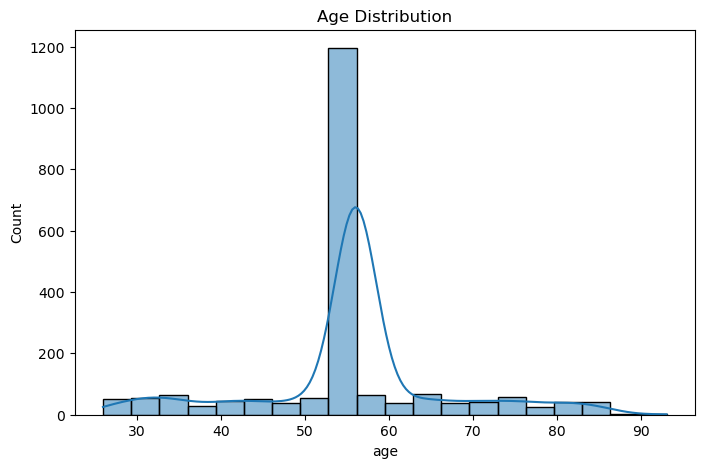

In [54]:
#Plot settings
plt.figure(figsize=(8, 5))
sns.histplot(master_df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

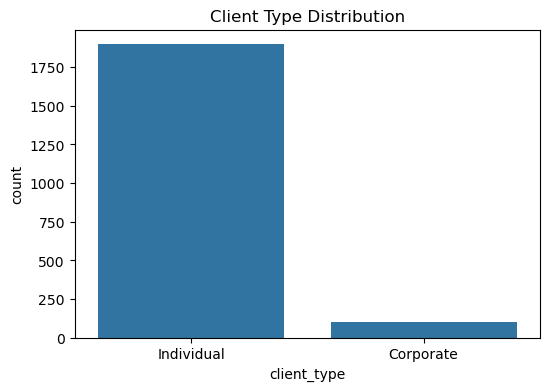

In [55]:
#Client type count
plt.figure(figsize=(6, 4))
sns.countplot(data=master_df, x='client_type')
plt.title("Client Type Distribution")
plt.show()

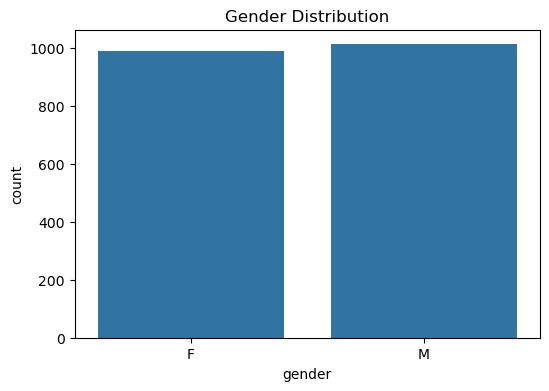

In [56]:
#Gender count
plt.figure(figsize=(6, 4))
sns.countplot(data=master_df, x='gender')
plt.title("Gender Distribution")
plt.show()

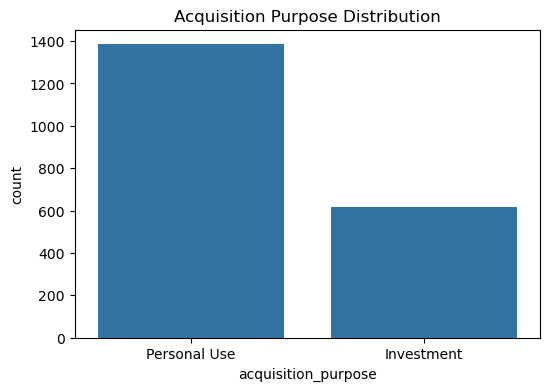

In [57]:
#Acquisition purpose
plt.figure(figsize=(6, 4))
sns.countplot(data=master_df, x='acquisition_purpose')
plt.title("Acquisition Purpose Distribution")
plt.show()

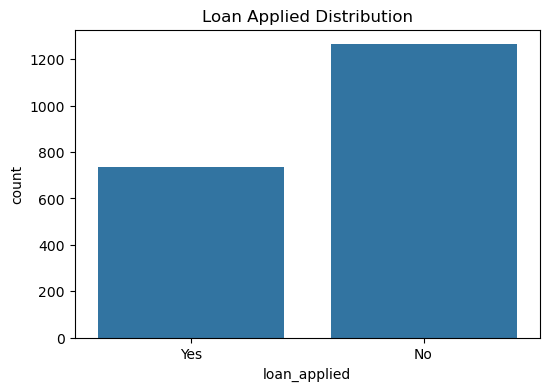

In [58]:
#Loan applied
plt.figure(figsize=(6, 4))
sns.countplot(data=master_df, x='loan_applied')
plt.title("Loan Applied Distribution")
plt.show()

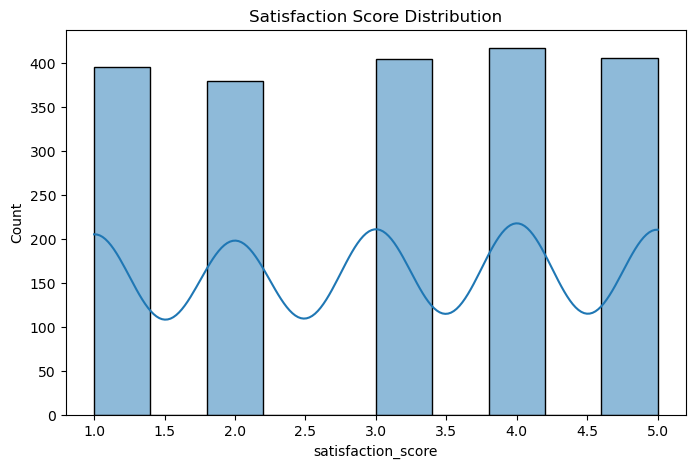

In [59]:
#Satisfaction score
plt.figure(figsize=(8, 5))
sns.histplot(master_df['satisfaction_score'], bins=10, kde=True)
plt.title("Satisfaction Score Distribution")
plt.show()

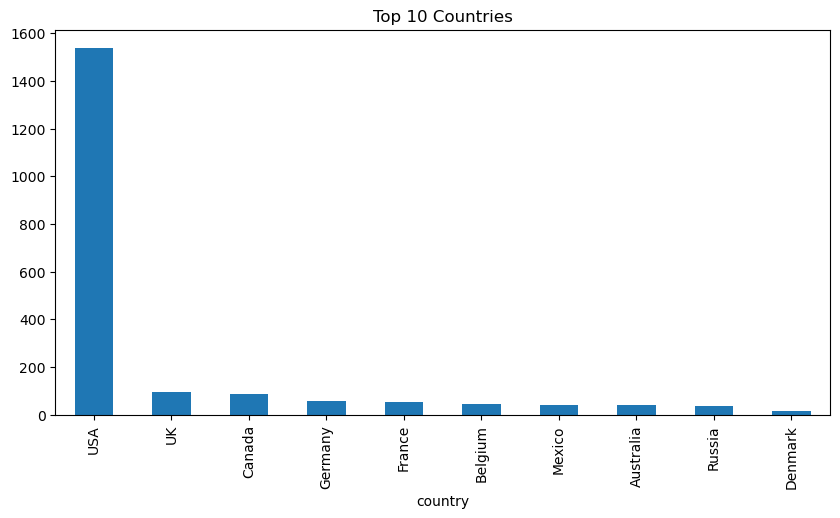

In [60]:
#Country distribution
plt.figure(figsize=(10, 5))
master_df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

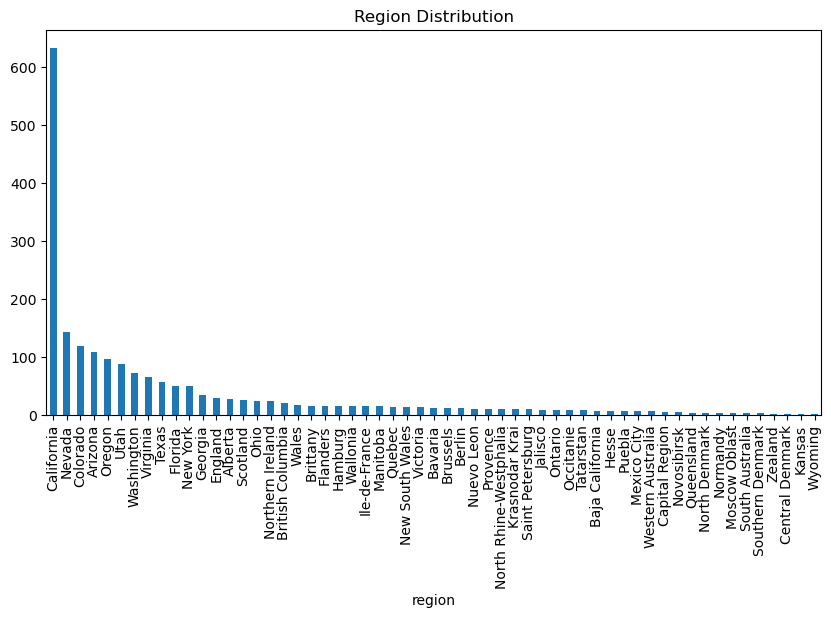

In [61]:
#Region distribution
plt.figure(figsize=(10, 5))
master_df['region'].value_counts().plot(kind='bar')
plt.title("Region Distribution")
plt.show()

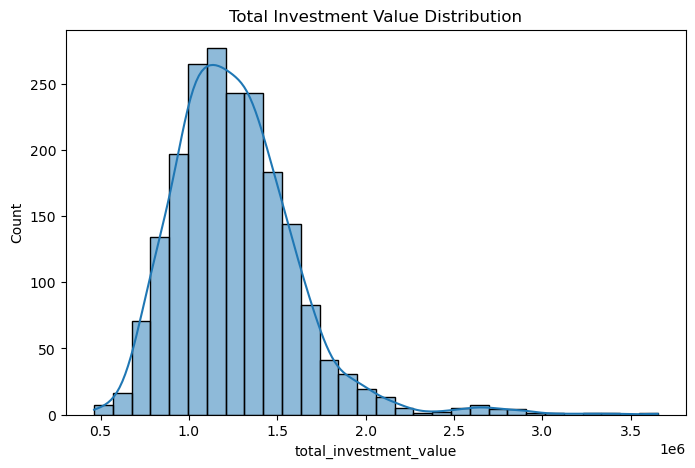

In [62]:
 #Total investment value distribution
plt.figure(figsize=(8, 5))
sns.histplot(master_df['total_investment_value'], bins=30, kde=True)
plt.title("Total Investment Value Distribution")
plt.show()

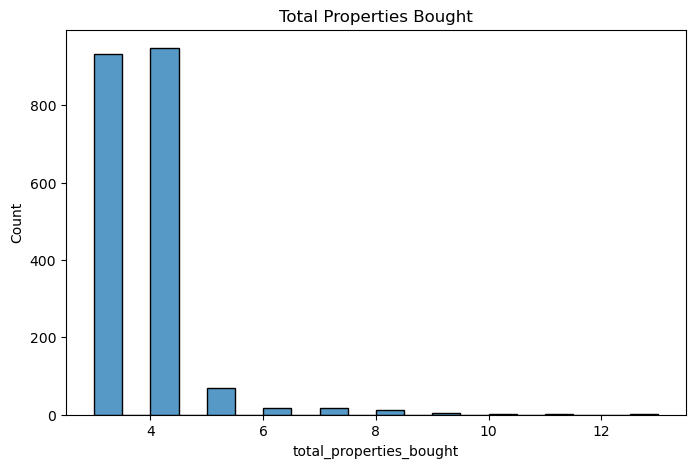

In [63]:
#Property count distribution
plt.figure(figsize=(8, 5))
sns.histplot(master_df['total_properties_bought'], bins=20, kde=False)
plt.title("Total Properties Bought")
plt.show()

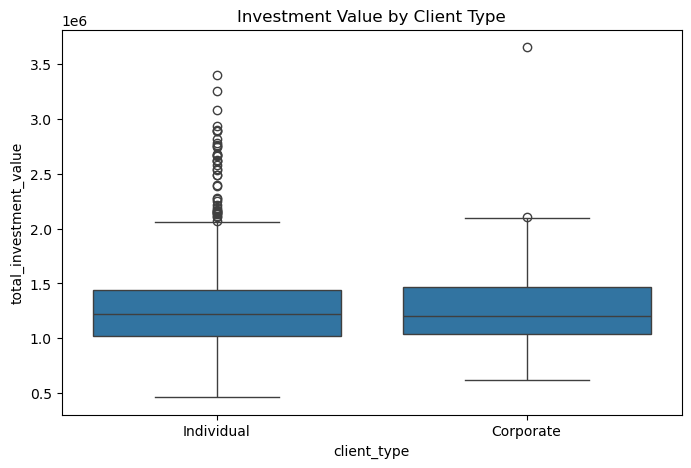

In [64]:
#Spend by client type
plt.figure(figsize=(8, 5))
sns.boxplot(data=master_df, x='client_type', y='total_investment_value')
plt.title("Investment Value by Client Type")
plt.show()

### Observation
- Most buyers belong to the Individual client type.
- A large portion of buyers purchased for Personal Use.
- Loan dependency appears higher among lower-spending buyers.
- Some clients show very high total investment values, suggesting premium or institutional buyers.

## Data Preparation for Clustering

In [67]:
features = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel',
    'age',
    'satisfaction_score',
    'total_properties_bought',
    'total_investment_value',
    'avg_property_value',
    'avg_floor_area',
    'purchase_recency_days'
]

In [68]:
features = [col for col in features if col in master_df.columns]
cluster_df = master_df[features].copy()

In [69]:
#Separate numeric and categorical columns
categorical_cols = cluster_df.select_dtypes(include='object').columns.tolist()
numeric_cols = cluster_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [70]:
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']
Numeric columns: ['age', 'satisfaction_score', 'total_properties_bought', 'total_investment_value', 'avg_property_value', 'avg_floor_area', 'purchase_recency_days']


In [71]:
#Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [72]:
X = preprocessor.fit_transform(cluster_df)

## Elbow Method

In [74]:
inertia = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

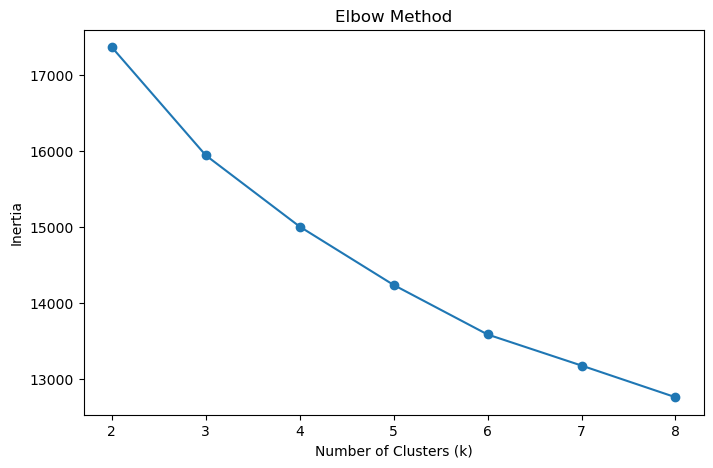

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

## Silhouette Score

In [77]:
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

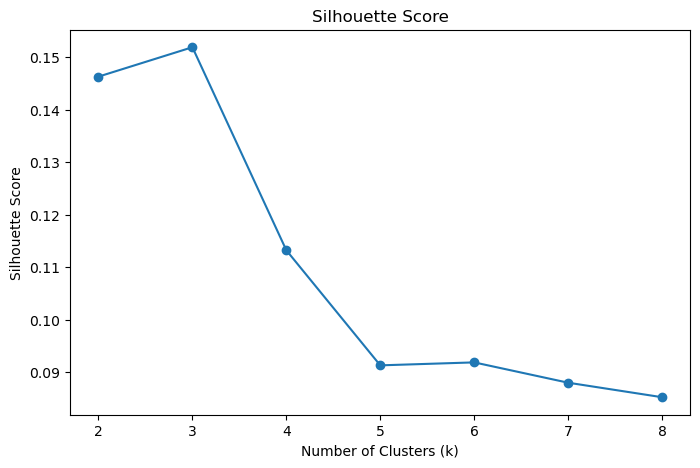

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [79]:
#scores
for k, score in zip(k_values, sil_scores):
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.1463
k=3, silhouette score=0.1519
k=4, silhouette score=0.1132
k=5, silhouette score=0.0913
k=6, silhouette score=0.0918
k=7, silhouette score=0.0880
k=8, silhouette score=0.0852


### Cluster Selection
Based on the elbow method and silhouette score, the optimal number of clusters was selected as 4. This also aligns well with the expected business segmentation structure for buyer profiling.

## K-Means Clustering

In [82]:
best_k = 4

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
master_df['cluster'] = kmeans_final.fit_predict(X)

In [83]:
#Check cluster counts:
master_df['cluster'].value_counts()

cluster
1    783
3    682
2    456
0     79
Name: count, dtype: int64

## Hierarchical Clustering

In [85]:
hierarchical = AgglomerativeClustering(n_clusters=best_k)
master_df['hierarchical_cluster'] = hierarchical.fit_predict(X.toarray() if hasattr(X, "toarray") else X)

In [86]:
master_df['hierarchical_cluster'].value_counts()

hierarchical_cluster
0    1050
3     465
1     441
2      44
Name: count, dtype: int64

## Cluster Profiling

In [88]:
#Now summarize numeric columns:
cluster_summary = master_df.groupby('cluster')[[
    'age',
    'satisfaction_score',
    'total_properties_bought',
    'total_investment_value',
    'avg_property_value',
    'avg_floor_area',
    'purchase_recency_days'
]].mean().round(2)

cluster_summary

,age,satisfaction_score,total_properties_bought,total_investment_value,avg_property_value,avg_floor_area,purchase_recency_days
cluster,,,,,,,
0,60.67,3.59,6.48,2191205.03,342329.40,1129.12,212.63
1,54.99,3.01,3.67,1101297.72,300037.94,997.70,203.75
2,56.40,2.90,3.34,1055792.44,317087.56,1056.59,481.12
3,55.44,3.07,3.51,1471976.98,421721.78,1382.34,277.61


In [89]:
#Find dominant category values
for col in ['client_type', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']:
    if col in master_df.columns:
        print(f"\nTop value of {col} in each cluster:")
        print(master_df.groupby('cluster')[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))


Top value of client_type in each cluster:
cluster
0    Individual
1    Individual
2    Individual
3    Individual
Name: client_type, dtype: object

Top value of country in each cluster:
cluster
0    USA
1    USA
2    USA
3    USA
Name: country, dtype: object

Top value of region in each cluster:
cluster
0    California
1    California
2    California
3    California
Name: region, dtype: object

Top value of acquisition_purpose in each cluster:
cluster
0    Personal Use
1    Personal Use
2    Personal Use
3    Personal Use
Name: acquisition_purpose, dtype: object

Top value of loan_applied in each cluster:
cluster
0    No
1    No
2    No
3    No
Name: loan_applied, dtype: object

Top value of referral_channel in each cluster:
cluster
0    Website
1    Website
2    Website
3    Website
Name: referral_channel, dtype: object


In [90]:
#Cluster size
master_df['cluster'].value_counts().sort_index()

cluster
0     79
1    783
2    456
3    682
Name: count, dtype: int64

In [91]:
cluster_name_map = {
    0: 'First-Time Buyers',
    1: 'Global Investors',
    2: 'Corporate Buyers',
    3: 'Luxury Investors'
}

master_df['buyer_segment'] = master_df['cluster'].map(cluster_name_map)

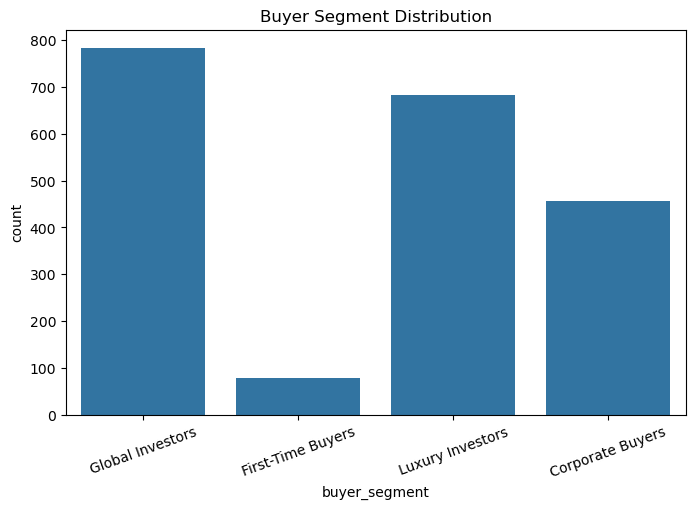

In [92]:
#Segment distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='buyer_segment')
plt.title("Buyer Segment Distribution")
plt.xticks(rotation=20)
plt.show()

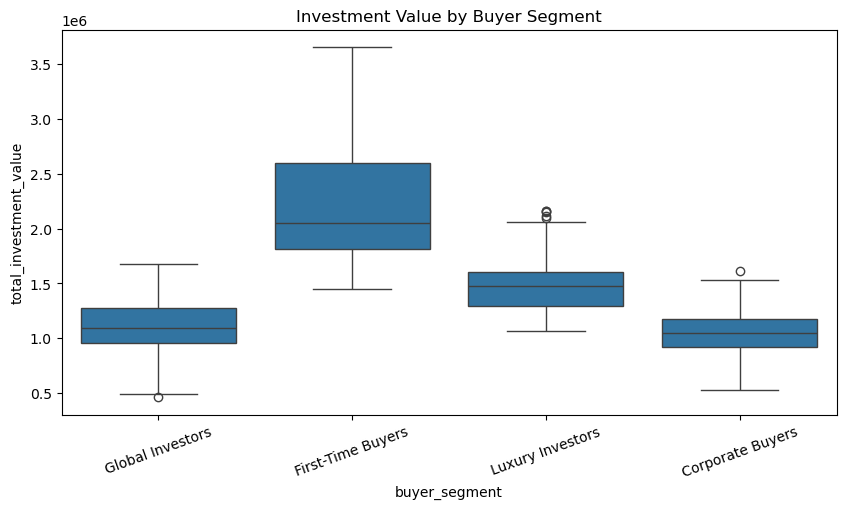

In [93]:
#Investment value by segment
plt.figure(figsize=(10, 5))
sns.boxplot(data=master_df, x='buyer_segment', y='total_investment_value')
plt.title("Investment Value by Buyer Segment")
plt.xticks(rotation=20)
plt.show()

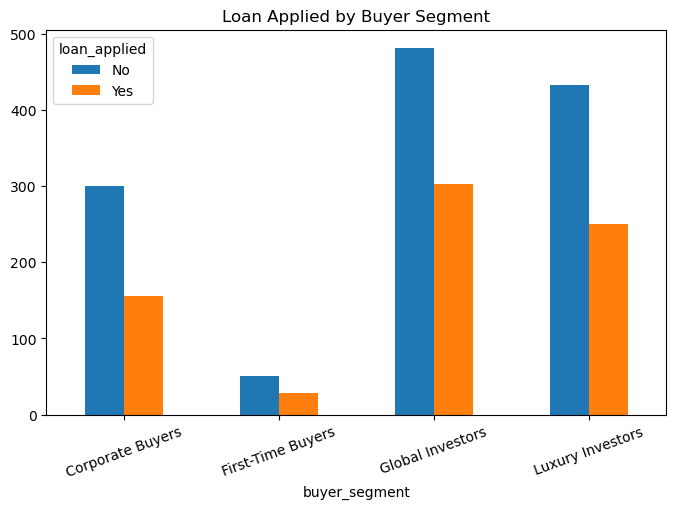

In [94]:
#Loan behavior by segment
loan_segment = pd.crosstab(master_df['buyer_segment'], master_df['loan_applied'])
loan_segment.plot(kind='bar', figsize=(8, 5))
plt.title("Loan Applied by Buyer Segment")
plt.xticks(rotation=20)
plt.show()

## Key Insights
- One segment appears to represent younger, loan-dependent buyers purchasing mainly for personal use.
- Another segment contains high-value buyers with stronger investment patterns.
- Corporate or organizational buyers show higher purchase volumes and higher overall spending.
- Certain regions contribute more strongly to investment-focused buyer behavior.

In [96]:
master_df.to_csv("clustered_buyers_output.csv", index=False)